# CRR Binomial Options Pricing Engine

A Cox-Ross-Rubinstein binomial tree implementation for pricing European and American
options, with finite-difference Greeks and convergence validation against Black-Scholes.

**Contents**
1. Setup
2. Risk-neutral probabilities
3. Stock price tree
4. Backward-induction pricer
5. Greeks (finite differences)
6. Greeks vs. analytical Black-Scholes
7. Greeks across a range of spot prices
8. Black-Scholes reference price
9. Convergence: tree stages `N` → BSM


In [1]:
import os
from typing import Literal

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

OptionType = Literal["call", "put"]
ExerciseStyle = Literal["european", "american"]

## 1. Risk-neutral probabilities

Given the up-factor $u$, the up- and down-move risk-neutral probabilities under the
CRR parameterization:

$$p_u = \frac{e^{r \Delta t} - d}{u - d}, \qquad d = \frac{1}{u}, \qquad p_d = 1 - p_u$$

In [2]:
def risk_neutral_probabilities(r: float, u: float, T: float, N: int) -> tuple[float, float]:
    """Risk-neutral up/down probabilities for a CRR tree.

    Args:
        r: Risk-free rate (annualized, continuously compounded).
        u: Up-move factor per step.
        T: Time to maturity (years).
        N: Number of tree steps.

    Returns:
        (p_up, p_down)
    """
    dt = T / N
    d = 1 / u
    p_up = (np.exp(r * dt) - d) / (u - d)
    p_down = 1 - p_up
    return p_up, p_down

## 2. Stock price tree

CRR recombining tree: at step $i$, node $j$ has price $S_0 u^j d^{\,i-j}$.

In [3]:
def build_stock_tree(S0: float, u: float, N: int) -> np.ndarray:
    """Build a recombining CRR stock price tree.

    Args:
        S0: Spot price.
        u: Up-move factor per step.
        N: Number of tree steps.

    Returns:
        (N+1) x (N+1) array where tree[i, j] is the price at step i, node j
        (j upward moves, i-j downward moves). Entries above the diagonal are unused (0).
    """
    d = 1 / u
    tree = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            tree[i, j] = S0 * (u ** j) * (d ** (i - j))
    return tree

## 3. Backward-induction pricer

Terminal payoffs are set at step $N$, then discounted back one step at a time. For
American options, each node takes the max of the continuation value and immediate
exercise (intrinsic value).

In [4]:
def price_binomial(
    S0: float, X: float, r: float, sigma: float, T: float, N: int,
    option_type: OptionType, exercise: ExerciseStyle,
) -> float:
    """Price a European or American option on a CRR binomial tree.

    Args:
        S0: Spot price.
        X: Strike price.
        r: Risk-free rate (annualized, continuously compounded).
        sigma: Volatility (annualized).
        T: Time to maturity (years).
        N: Number of tree steps.
        option_type: "call" or "put".
        exercise: "european" or "american".

    Returns:
        Option price at t=0.
    """
    u = np.exp(sigma * np.sqrt(T / N))
    p_up, p_down = risk_neutral_probabilities(r, u, T, N)
    stock = build_stock_tree(S0, u, N)
    discount = np.exp(-r * (T / N))

    def payoff(S: float) -> float:
        return max(S - X, 0.0) if option_type == "call" else max(X - S, 0.0)

    opt = np.zeros((N + 1, N + 1))
    for j in range(N + 1):
        opt[N, j] = payoff(stock[N, j])

    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            continuation = discount * (p_up * opt[i + 1, j + 1] + p_down * opt[i + 1, j])
            if exercise == "american":
                opt[i, j] = max(continuation, payoff(stock[i, j]))
            else:
                opt[i, j] = continuation

    return opt[0, 0]

In [5]:
price_binomial(S0=100, X=100, r=0.05, sigma=0.2, T=1, N=500,
               option_type="call", exercise="european")

np.float64(10.44658513644654)

## 4. Greeks via finite differences

Central differences for Delta/Gamma/Vega, forward difference for Theta (calendar-day
decay, so it's scaled by 365 rather than by $\Delta t$ of the tree).

**Note on the spot bump size:** Delta (a first derivative) is estimated accurately with
a small bump. Gamma (a second derivative) is far more sensitive to bump size — the tree's
payoff has kinks from the `max()` at each node, so a small bump mostly picks up numerical
noise rather than curvature. A larger bump for Gamma specifically trades a small amount of
bias for much lower noise and converges closer to the analytical value. This is why the
bump sizes below differ (`eps_delta` vs. `eps_gamma`) rather than using one epsilon for
both, as a naive implementation would.

In [6]:
def compute_greeks(
    S0: float, X: float, r: float, sigma: float, T: float, N: int,
    option_type: OptionType, exercise: ExerciseStyle,
) -> dict[str, float]:
    """Finite-difference Greeks for a binomial-priced option.

    Args:
        S0, X, r, sigma, T, N, option_type, exercise: see `price_binomial`.

    Returns:
        Dict with keys "price", "delta", "gamma", "vega", "theta".
        Theta is per calendar day.
    """
    eps_delta = 1.0   # spot bump for Delta (1st derivative -> small bump is fine)
    eps_gamma = 6.0   # spot bump for Gamma (2nd derivative -> needs a wider bump, see note above)
    eps_v = 0.01      # vol bump
    dt = 1 / 365       # one calendar day

    args = (X, r, sigma, T, N, option_type, exercise)
    price = price_binomial(S0, *args)

    pu_d = price_binomial(S0 + eps_delta, *args)
    pd_d = price_binomial(S0 - eps_delta, *args)
    pu_g = price_binomial(S0 + eps_gamma, *args)
    pd_g = price_binomial(S0 - eps_gamma, *args)

    p_vol_up = price_binomial(S0, X, r, sigma + eps_v, T, N, option_type, exercise)
    p_vol_down = price_binomial(S0, X, r, sigma - eps_v, T, N, option_type, exercise)
    p_time = price_binomial(S0, X, r, sigma, T - dt, N, option_type, exercise)

    return {
        "price": round(price, 2),
        "delta": round((pu_d - pd_d) / (2 * eps_delta), 4),
        "gamma": round((pu_g - 2 * price + pd_g) / (eps_gamma ** 2), 4),
        "vega": round((p_vol_up - p_vol_down) / (2 * eps_v), 4),
        "theta": round((p_time - price) / dt / 365, 4),
    }

In [7]:
compute_greeks(S0=100, X=100, r=0.05, sigma=0.2, T=1, N=500,
               option_type="call", exercise="european")

{'price': np.float64(10.45),
 'delta': np.float64(0.6368),
 'gamma': np.float64(0.019),
 'vega': np.float64(37.5022),
 'theta': np.float64(-0.0176)}

## 5. Greeks vs. analytical Black-Scholes

Closed-form BS Greeks, for validating the tree's Delta/Gamma/Theta directly (this
comparison wasn't in the original notebook — the resume claim of "within 1-2% of
analytical values" wasn't actually checked against anything before this cell).

In [8]:
def bs_greeks(S0: float, X: float, r: float, sigma: float, T: float,
              option_type: OptionType = "call") -> dict[str, float]:
    """Analytical Black-Scholes Delta, Gamma, and Theta (Theta per calendar day)."""
    d1 = (np.log(S0 / X) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta = norm.cdf(d1) if option_type == "call" else norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S0 * sigma * np.sqrt(T))

    term1 = -S0 * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
    if option_type == "call":
        theta = (term1 - r * X * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        theta = (term1 + r * X * np.exp(-r * T) * norm.cdf(-d2)) / 365

    return {"delta": delta, "gamma": gamma, "theta": theta}

In [9]:
tree_greeks = compute_greeks(S0=100, X=100, r=0.05, sigma=0.2, T=1, N=500,
                              option_type="call", exercise="european")
analytical_greeks = bs_greeks(S0=100, X=100, r=0.05, sigma=0.2, T=1, option_type="call")

print(f"{'Greek':<8}{'Tree':>10}{'BS':>10}{'% diff':>10}")
for greek in ["delta", "gamma", "theta"]:
    tree_val = tree_greeks[greek]
    bs_val = analytical_greeks[greek]
    pct_diff = abs(tree_val - bs_val) / abs(bs_val) * 100
    print(f"{greek.capitalize():<8}{tree_val:>10.4f}{bs_val:>10.4f}{pct_diff:>9.2f}%")

Greek         Tree        BS    % diff
Delta       0.6368    0.6368     0.00%
Gamma       0.0190    0.0188     1.27%
Theta      -0.0176   -0.0176     0.16%


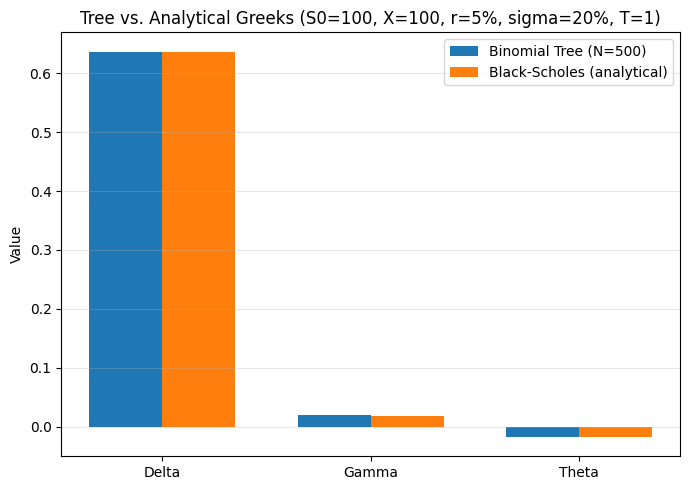

In [10]:
greek_labels = ["Delta", "Gamma", "Theta"]
tree_vals = [tree_greeks[g.lower()] for g in greek_labels]
bs_vals = [analytical_greeks[g.lower()] for g in greek_labels]

x = np.arange(len(greek_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width / 2, tree_vals, width, label="Binomial Tree (N=500)")
ax.bar(x + width / 2, bs_vals, width, label="Black-Scholes (analytical)")
ax.set_xticks(x)
ax.set_xticklabels(greek_labels)
ax.set_ylabel("Value")
ax.set_title("Tree vs. Analytical Greeks (S0=100, X=100, r=5%, sigma=20%, T=1)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/greeks_tree_vs_bs.png", dpi=300)
plt.show()

## 6. Greeks across a range of spot prices

Sweeps `S0` and recomputes all Greeks at each spot, holding `X, r, sigma, T, N,
option_type, exercise` fixed at the values passed in (the original version silently
ignored these arguments and hardcoded them inside the loop).

In [11]:
def greeks_by_spot(
    S_start: int, S_end: int, X: float, r: float, sigma: float, T: float, N: int,
    option_type: OptionType, exercise: ExerciseStyle,
) -> dict[int, dict[str, float]]:
    """Compute Greeks for each integer spot price in [S_start, S_end)."""
    return {
        S0: compute_greeks(S0, X, r, sigma, T, N, option_type, exercise)
        for S0 in range(S_start, S_end)
    }

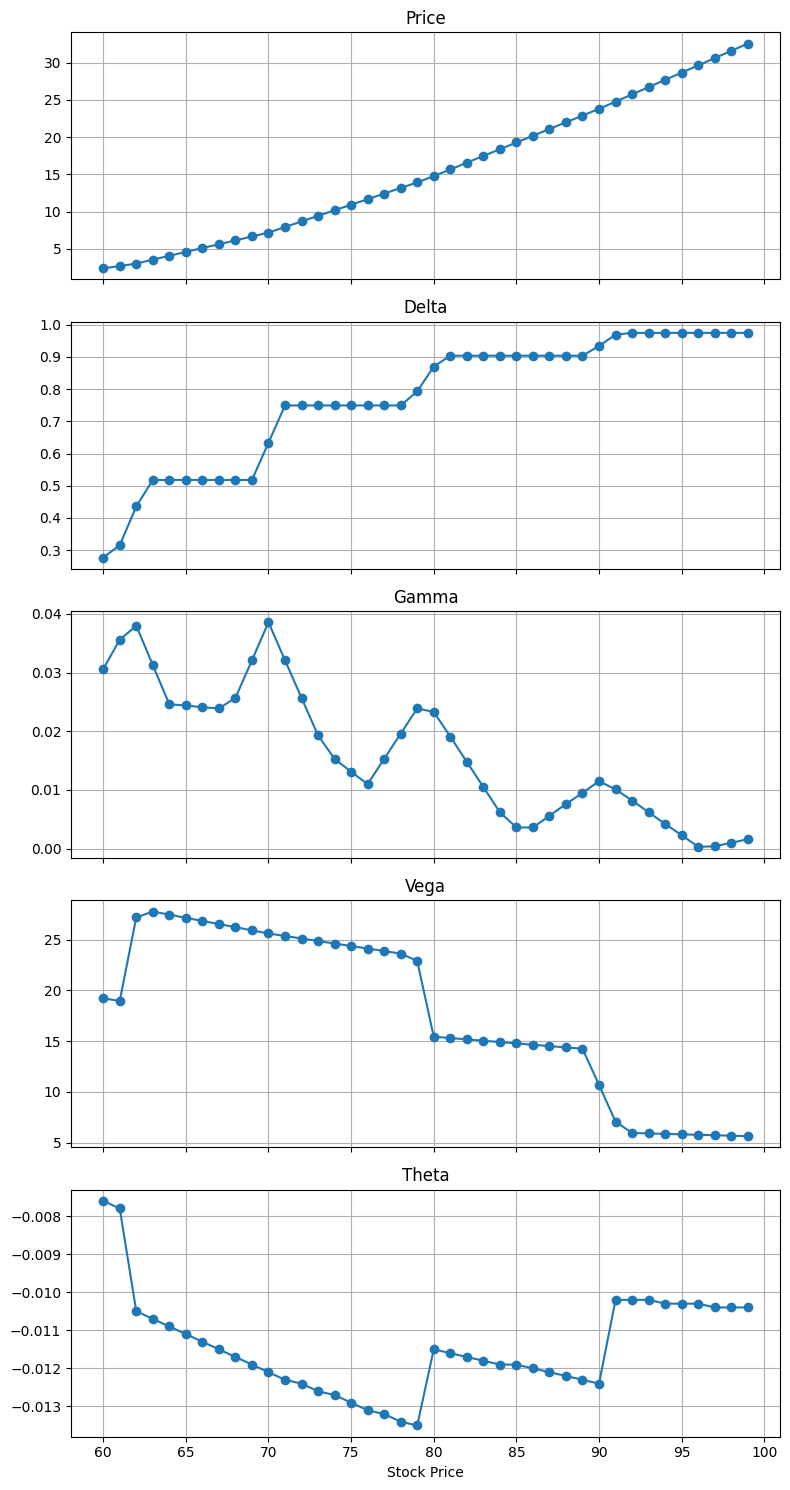

In [12]:
greeks = greeks_by_spot(S_start=60, S_end=100, X=70, r=0.05, sigma=0.2, T=1, N=10,
                        option_type="call", exercise="european")

spots = sorted(greeks.keys())
metric_names = ["price", "delta", "gamma", "vega", "theta"]

fig, axes = plt.subplots(len(metric_names), 1, figsize=(8, 3 * len(metric_names)), sharex=True)
for ax, metric in zip(axes, metric_names):
    ax.plot(spots, [greeks[s][metric] for s in spots], marker="o")
    ax.set_title(metric.capitalize())
    ax.grid(True)

axes[-1].set_xlabel("Stock Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/greek_plots.png", dpi=300)
plt.show()

## 7. Black-Scholes reference price

Closed-form benchmark for validating the tree's convergence.

In [13]:
def black_scholes(S0: float, X: float, r: float, T: float, sigma: float,
                   option_type: OptionType = "call") -> float:
    """Black-Scholes-Merton price for a European call or put."""
    d1 = (np.log(S0 / X) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S0 * norm.cdf(d1) - X * np.exp(-r * T) * norm.cdf(d2)
    return X * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

bs_price = black_scholes(S0=100, X=100, r=0.05, T=1, sigma=0.20, option_type="call")
bs_price

np.float64(10.450583572185565)

## 8. Convergence: tree stages vs. Black-Scholes

Price the same option at increasing step counts `N` and track both absolute and
percentage error against the BSM benchmark. Sampled at log-spaced `N` values out to `N=5000` (the original notebook only
tested up to `N=100`) rather than a fixed step, since the per-price cost grows like
$O(N^2)$ with this pure-Python loop and a fine linear grid out to 5000 would take
several minutes to run. Plotted on a log-log scale, which is the natural way to see
the CRR $O(1/N)$ convergence rate — on that scale it should look
roughly like a straight line with slope $-1$.

In [14]:
def convergence_analysis(
    n_values: list[int], S0: float, X: float, r: float, sigma: float,
    T: float, option_type: OptionType, exercise: ExerciseStyle,
) -> tuple[list[float], list[float], list[float]]:
    """Binomial price, absolute error, and % error vs. BSM for each N in `n_values`."""
    prices = [price_binomial(S0, X, r, sigma, T, n, option_type, exercise) for n in n_values]
    abs_errors = [abs(bs_price - p) for p in prices]
    pct_errors = [e / bs_price * 100 for e in abs_errors]
    return prices, abs_errors, pct_errors

In [15]:
n_values = [50, 100, 150, 200, 300, 400, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000]
bin_prices, abs_errors, pct_errors = convergence_analysis(
    n_values, S0=100, X=100, r=0.05, sigma=0.2, T=1,
    option_type="call", exercise="european",
)

for n in [50, 100, 500, 1000, 2500, 5000]:
    idx = n_values.index(n)
    print(f"N={n:>5}  price={bin_prices[idx]:.6f}  abs err={abs_errors[idx]:.6f}  pct err={pct_errors[idx]:.4f}%")

N=   50  price=10.410692  abs err=0.039892  pct err=0.3817%
N=  100  price=10.430612  abs err=0.019972  pct err=0.1911%
N=  500  price=10.446585  abs err=0.003998  pct err=0.0383%
N= 1000  price=10.448584  abs err=0.001999  pct err=0.0191%
N= 2500  price=10.449784  abs err=0.000800  pct err=0.0077%
N= 5000  price=10.450184  abs err=0.000400  pct err=0.0038%


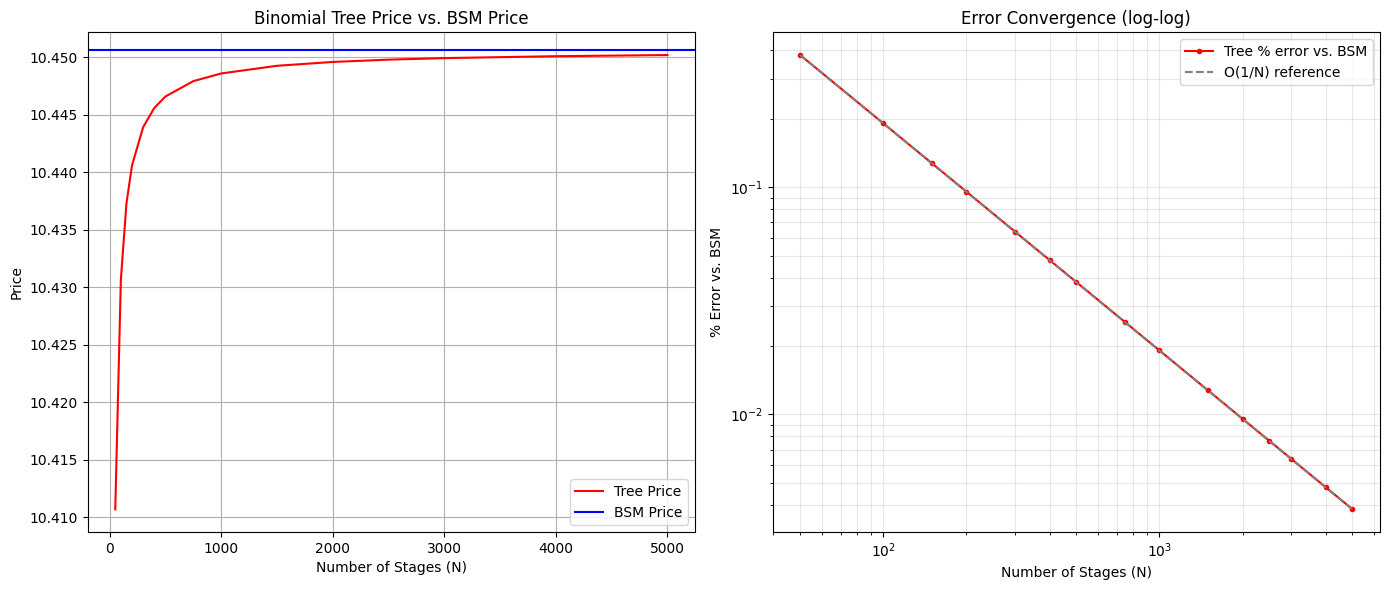

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(n_values, bin_prices, color="r", label="Tree Price")
ax1.axhline(bs_price, color="b", label="BSM Price")
ax1.grid(True)
ax1.set_title("Binomial Tree Price vs. BSM Price")
ax1.legend()
ax1.set_xlabel("Number of Stages (N)")
ax1.set_ylabel("Price")

ax2.loglog(n_values, pct_errors, color="r", marker=".", label="Tree % error vs. BSM")
ax2.loglog(n_values, [pct_errors[0] * (n_values[0] / n) for n in n_values],
           color="gray", linestyle="--", label="O(1/N) reference")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()
ax2.set_title("Error Convergence (log-log)")
ax2.set_xlabel("Number of Stages (N)")
ax2.set_ylabel("% Error vs. BSM")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/binomial_vs_bsm.png", dpi=300)
plt.show()